# Shamela — EDA

Exploratory analysis of `datasets/shamela/*.csv` (output of `scripts/prepare_shamela.py`,
one CSV per book), ahead of building a `preprocess_shamela.py` that mirrors
`preprocessing/preprocess_sadeed_tashkeela.py`.

Columns: `FILENAME` (book id), `DIACRRITIC` (diacritized Arabic text),
`NON_DIACRRITIC` (same text with diacritics stripped).

2,695 books, ~5GB total, spread across many small files rather than one big
one (unlike Sadeed_Tashkeela). Because of that, every full-corpus statistic
below is computed in a **single combined streaming pass** over all books -
running each check as its own separate pass would multiply per-file open/
parse overhead by the number of checks, across ~2,695 files each time.

In [1]:
from collections import Counter
import hashlib
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyarabic import araby

# notebooks -> repo root
SHAMELA_DIR = Path("../datasets/shamela")
BOOK_PATHS = sorted(SHAMELA_DIR.glob("*.csv"))

CHUNKSIZE = 50_000
MISMATCH_SAMPLE_SIZE = 50

TASHKEEL = set(araby.TASHKEEL)

NON_ARABIC_RATIO_THRESHOLD = 0.3
MIN_CHARS = 3
BARE_WORD_RATIO_THRESHOLD = 0.3

HTML_TAG_RE = re.compile(r"<[^>]*>")
TATWEEL = "\u0640"
TANWIN_FATH = "\u064B"
ALEF = "\u0627"
DASH_RUN_RE = re.compile(r"-{3,}")
DIGIT_RE = re.compile(r"\d+")


def is_arabic_letter(ch):
    return "\u0600" <= ch <= "\u06FF"


def is_arabic_letter_only(ch):
    return is_arabic_letter(ch) and ch.isalpha() and ch not in TASHKEEL


print(f"{len(BOOK_PATHS):,} book CSVs found")

2,695 book CSVs found


## Single combined pass over the whole corpus

Streams every book (chunk-wise, so one huge book can't blow up memory) and
updates every accumulator below in the same loop: schema/nulls, the
`NON_DIACRRITIC == strip_tashkeel(DIACRRITIC)` consistency check, length
distributions, character/diacritic vocab, per-book row counts, duplicate
detection, outlier flags, and the cleanup-step checks (HTML tags, tatweel,
tanwin order, NFC, dash runs, digits).

In [2]:
n_rows = 0
n_null = {"FILENAME": 0, "DIACRRITIC": 0, "NON_DIACRRITIC": 0}
n_empty = {"FILENAME": 0, "DIACRRITIC": 0, "NON_DIACRRITIC": 0}

n_match = 0
n_mismatch = 0
mismatches = []

char_lens = []
word_lens = []

char_freq = Counter()
diacritic_freq = Counter()

book_row_counts = {}

hash_counts = Counter()
hash_books = {}

n_no_diacritics = 0
n_non_arabic_dominant = 0
n_empty_diacritic_rows = 0
n_very_short = 0
n_high_bare_word_ratio = 0

n_html = 0
n_tatweel = 0
n_tanwin_before_alef = 0
n_tanwin_after_alef = 0
n_not_nfc = 0
n_dash_run = 0
n_digit_rows = 0

first_chunk_preview = None

for path in BOOK_PATHS:
    for chunk in pd.read_csv(
        path, chunksize=CHUNKSIZE, dtype=str, keep_default_na=False
    ):
        if first_chunk_preview is None:
            first_chunk_preview = chunk.copy()

        n_rows += len(chunk)
        book_row_counts[path.stem] = book_row_counts.get(path.stem, 0) + len(chunk)

        for col in n_null:
            n_null[col] += chunk[col].isna().sum()
            n_empty[col] += (chunk[col].fillna("").str.strip() == "").sum()

        char_lens.append(chunk["DIACRRITIC"].str.len().to_numpy())
        word_lens.append(chunk["DIACRRITIC"].str.split().str.len().to_numpy())

        stripped_col = chunk["DIACRRITIC"].map(araby.strip_tashkeel)
        match = stripped_col == chunk["NON_DIACRRITIC"]
        n_match += match.sum()
        n_mismatch += (~match).sum()
        if len(mismatches) < MISMATCH_SAMPLE_SIZE:
            need = MISMATCH_SAMPLE_SIZE - len(mismatches)
            for _, row in chunk.loc[~match].head(need).iterrows():
                mismatches.append(
                    {
                        "book": path.stem,
                        "DIACRRITIC": row["DIACRRITIC"][:120],
                        "NON_DIACRRITIC": row["NON_DIACRRITIC"][:120],
                        "stripped": araby.strip_tashkeel(row["DIACRRITIC"])[:120],
                    }
                )

        char_freq.update("".join(chunk["NON_DIACRRITIC"]))

        for text in chunk["DIACRRITIC"]:
            diacritic_freq.update(ch for ch in text if ch in TASHKEEL)

            h = hashlib.md5(text.encode("utf-8")).hexdigest()
            hash_counts[h] += 1
            hash_books.setdefault(h, set()).add(path.stem)

            stripped_text = text.strip()
            if not stripped_text:
                n_empty_diacritic_rows += 1
            else:
                if len(stripped_text) < MIN_CHARS:
                    n_very_short += 1
                if not any(ch in TASHKEEL for ch in text):
                    n_no_diacritics += 1
                non_arabic = sum(1 for ch in stripped_text if not is_arabic_letter(ch) and ch != " ")
                if non_arabic / len(stripped_text) > NON_ARABIC_RATIO_THRESHOLD:
                    n_non_arabic_dominant += 1

                real_words = [w for w in stripped_text.split() if any(is_arabic_letter_only(c) for c in w)]
                if real_words:
                    n_bare = sum(1 for w in real_words if not any(c in TASHKEEL for c in w))
                    if (n_bare / len(real_words)) > BARE_WORD_RATIO_THRESHOLD:
                        n_high_bare_word_ratio += 1

            if HTML_TAG_RE.search(text):
                n_html += 1
            if TATWEEL in text:
                n_tatweel += 1
            if (TANWIN_FATH + ALEF) in text:
                n_tanwin_before_alef += 1
            if (ALEF + TANWIN_FATH) in text:
                n_tanwin_after_alef += 1
            if unicodedata.normalize("NFC", text) != text:
                n_not_nfc += 1
            if DASH_RUN_RE.search(text):
                n_dash_run += 1
            if DIGIT_RE.search(text):
                n_digit_rows += 1

char_lens = np.concatenate(char_lens)
word_lens = np.concatenate(word_lens)

print(f"{n_rows:,} rows across {len(BOOK_PATHS):,} books")

17,671,222 rows across 2,695 books


## 1. Schema & sanity checks

In [3]:
print("columns:", list(first_chunk_preview.columns))
print("dtypes:\n", first_chunk_preview.dtypes)
print()
display(first_chunk_preview.head())
print()
print(f"null counts:  {n_null}")
print(f"empty counts: {n_empty}")

columns: ['FILENAME', 'DIACRRITIC', 'NON_DIACRRITIC']
dtypes:
 FILENAME          str
DIACRRITIC        str
NON_DIACRRITIC    str
dtype: object



,FILENAME,DIACRRITIC,NON_DIACRRITIC
0,10002,قال تعالى في سورة النحل وَنَزّلْنَا عَلَيْكَ ا...,قال تعالى في سورة النحل ونزلنا عليك الكتاب تبي...
1,10002,لَا تُحَرّكْ بِهِ لِسَانَكَ لِتَعْجَلَ بِهِ إِ...,لا تحرك به لسانك لتعجل به إن علينا جمعه وقرآنه...
2,10002,هُوَ الّذِي بَعَثَ فِي الْأُمّيّينَ رَسُولًا م...,هو الذي بعث في الأميين رسولا منهم يتلو عليهم آ...
3,10002,لَا تُحَرّكْ بِهِ لِسَانَكَ لِتَعْجَلَ بِهِ إِ...,لا تحرك به لسانك لتعجل به إن علينا جمعه وقرآنه...
4,10002,قال جل شأنه في سورة القيامة لَا تُحَرّكْ بِهِ ...,قال جل شأنه في سورة القيامة لا تحرك به لسانك ل...



null counts:  {'FILENAME': np.int64(0), 'DIACRRITIC': np.int64(0), 'NON_DIACRRITIC': np.int64(0)}
empty counts: {'FILENAME': np.int64(0), 'DIACRRITIC': np.int64(0), 'NON_DIACRRITIC': np.int64(0)}


## 2. Consistency check: `NON_DIACRRITIC == strip_tashkeel(DIACRRITIC)`

In [4]:
total = n_match + n_mismatch
print(f"match:    {n_match:,} ({n_match / total:.4%})")
print(f"mismatch: {n_mismatch:,} ({n_mismatch / total:.4%})")
display(pd.DataFrame(mismatches))

match:    17,671,222 (100.0000%)
mismatch: 0 (0.0000%)


""


## 3. Text length distributions

In [5]:
percentiles = [50, 90, 95, 99, 100]
char_pcts = np.percentile(char_lens, percentiles)
word_pcts = np.percentile(word_lens, percentiles)

print("char length percentiles:", dict(zip(percentiles, char_pcts.round(1))))
print("word length percentiles:", dict(zip(percentiles, word_pcts.round(1))))

char length percentiles: {50: np.float64(71.0), 90: np.float64(204.0), 95: np.float64(250.0), 99: np.float64(310.0), 100: np.float64(489.0)}
word length percentiles: {50: np.float64(9.0), 90: np.float64(25.0), 95: np.float64(31.0), 99: np.float64(38.0), 100: np.float64(40.0)}


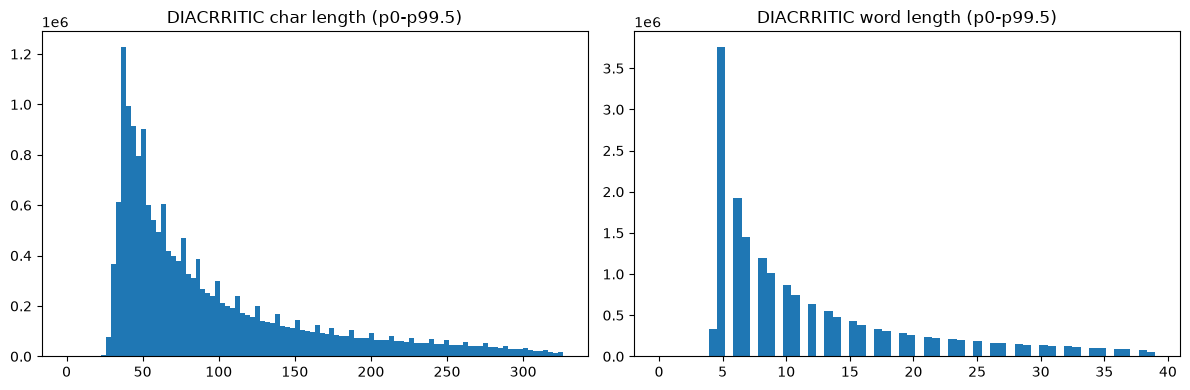

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_lens, bins=100, range=(0, np.percentile(char_lens, 99.5)))
axes[0].set_title("DIACRRITIC char length (p0-p99.5)")
axes[1].hist(word_lens, bins=60, range=(0, np.percentile(word_lens, 99.5)))
axes[1].set_title("DIACRRITIC word length (p0-p99.5)")
plt.tight_layout()
plt.show()

## 4. Character-level vocabulary

In [7]:
print(f"{len(char_freq):,} distinct characters in NON_DIACRRITIC")

char_freq_df = (
    pd.DataFrame(char_freq.items(), columns=["char", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
display(char_freq_df.head(20))

92 distinct characters in NON_DIACRRITIC


,char,count
0,,192570393
1,ا,111619287
2,ل,99995379
3,ن,57589493
4,ي,55767784
5,م,54132359
6,و,49223798
7,ب,38804341
8,ه,38256061
9,ر,34598961


In [8]:
char_freq_df["is_arabic_range"] = char_freq_df["char"].map(is_arabic_letter)
non_arabic = char_freq_df[~char_freq_df["is_arabic_range"] & (char_freq_df["char"] != " ")]
print(f"{len(non_arabic):,} distinct non-Arabic-range characters, "
      f"{non_arabic['count'].sum():,} total occurrences")
display(non_arabic.head(40))

48 distinct non-Arabic-range characters, 1,125,281 total occurrences


,char,count,is_arabic_range
37,¬,330285,False
38,﵁,172487,False
40,…,96534,False
41,﷿,87309,False
42,⦘,63614,False
43,⦗,63614,False
44,﵇,53011,False
45,﵀,51256,False
46,﵄,46602,False
47,•,40164,False


## 5. Diacritic mark frequency / class balance

,name,char,count
0,فتحة,َ,286825404
3,كسرة,ِ,121564913
2,سكون,ْ,109216713
5,ضمة,ُ,80003593
1,شدة,ّ,45832464
6,كسرتان,ٍ,8346234
4,فتحتان,ً,5679014
7,ضمتان,ٌ,5229997


C:\Users\family\AppData\Local\Temp\ipykernel_6976\3818774613.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(diac_df["name"], rotation=45, ha="right")


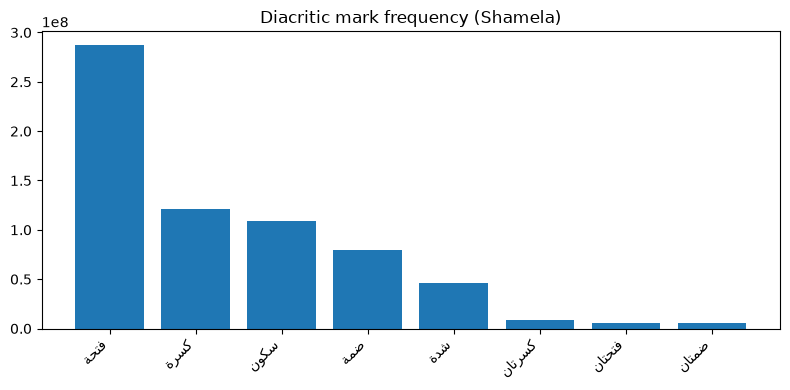

In [9]:
diac_df = pd.DataFrame(
    [(araby.name(ch, ch), ch, cnt) for ch, cnt in diacritic_freq.items()],
    columns=["name", "char", "count"],
).sort_values("count", ascending=False)
display(diac_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(diac_df["name"], diac_df["count"])
ax.set_xticklabels(diac_df["name"], rotation=45, ha="right")
ax.set_title("Diacritic mark frequency (Shamela)")
plt.tight_layout()
plt.show()

## 6. Book breakdown

In [10]:
book_counts_df = pd.DataFrame(
    book_row_counts.items(), columns=["book", "n_rows"]
).sort_values("n_rows", ascending=False)

print(f"{len(book_counts_df):,} books")
display(book_counts_df.describe())
display(book_counts_df.head(10))
display(book_counts_df.tail(10))

2,695 books


,n_rows
count,2695.000000
mean,6557.039703
std,20591.264804
min,200.000000
25%,357.500000
50%,775.000000
75%,3094.000000
max,329810.000000


,book,n_rows
579,13285,329810
870,1673,271879
155,11430,254418
2424,9059,205552
881,1687,199178
1297,23635,193641
2277,8176,190258
2258,7861,173624
2640,9776,172889
2121,7030,162750


,book,n_rows
2391,8635,201
1713,36056,201
2000,6002,201
2191,7663,201
1699,35083,200
1026,20594,200
1425,29464,200
843,1575,200
152,11426,200
794,150305,200


## 7. Duplicate detection

In [11]:
n_dup_groups = sum(1 for c in hash_counts.values() if c > 1)
n_dup_rows = sum(c for c in hash_counts.values() if c > 1)
n_cross_book_groups = sum(1 for h, c in hash_counts.items() if c > 1 and len(hash_books[h]) > 1)

print(f"{n_dup_groups:,} distinct duplicated texts, {n_dup_rows:,} rows involved "
      f"({n_dup_rows / n_rows:.2%} of corpus)")
print(f"{n_cross_book_groups:,} of those duplicate groups span more than one book "
      f"(train/val leakage risk if split by row instead of by book)")

996,093 distinct duplicated texts, 4,247,873 rows involved (24.04% of corpus)
811,331 of those duplicate groups span more than one book (train/val leakage risk if split by row instead of by book)


## 8. Outlier / noise detection

Same criteria as the Sadeed_Tashkeela EDA, plus an explicit check for the
"undiacritized intro + diacritized quote" pattern already spotted by hand in
one book (e.g. "قال تعالى في سورة النحل وَنَزَّلْنَا ..."): a row whose
diacritic-per-word average passes but where a large share of its *real*
(letter-containing) words carry zero diacritics.

In [12]:
print(f"fully undiacritized rows: {n_no_diacritics:,}")
print(f"non-Arabic-dominant rows (>{NON_ARABIC_RATIO_THRESHOLD:.0%}): {n_non_arabic_dominant:,}")
print(f"empty/whitespace-only rows: {n_empty_diacritic_rows:,}")
print(f"very short rows (<{MIN_CHARS} chars): {n_very_short:,}")
print(f"rows with >{BARE_WORD_RATIO_THRESHOLD:.0%} bare real words: {n_high_bare_word_ratio:,}")

fully undiacritized rows: 0
non-Arabic-dominant rows (>30%): 2
empty/whitespace-only rows: 0
very short rows (<3 chars): 0
rows with >30% bare real words: 151,832


## 9. Cleanup-step checks (mirroring Sadeed_Tashkeela's steps a/b/g)

Checked directly rather than assumed, since Shamela is a different source
pipeline than Sadeed_Tashkeela and may not share the same quirks.

In [13]:
print(f"rows with HTML/XML-looking tags: {n_html:,}")
print(f"rows with tatweel: {n_tatweel:,}")
print(f"tanwin-before-alef (correct order, mark on consonant): {n_tanwin_before_alef:,}")
print(f"tanwin-after-alef (wrong order): {n_tanwin_after_alef:,}")
print(f"rows not NFC-normalized: {n_not_nfc:,} ({n_not_nfc / n_rows:.1%})")
print(f"rows with a 3+ dash run: {n_dash_run:,}")
print(f"rows containing digits: {n_digit_rows:,}")

rows with HTML/XML-looking tags: 0
rows with tatweel: 153,935
tanwin-before-alef (correct order, mark on consonant): 3,229,556
tanwin-after-alef (wrong order): 160
rows not NFC-normalized: 3,525,573 (20.0%)
rows with a 3+ dash run: 0
rows containing digits: 0


## 10. Summary — parameters for `preprocess_shamela.py`

In [14]:
import json

summary = {
    "n_rows": int(n_rows),
    "n_books": len(book_counts_df),
    "consistency_match_rate": float(n_match / total),
    "char_len_p50": float(char_pcts[0]),
    "char_len_p90": float(char_pcts[1]),
    "char_len_p95": float(char_pcts[2]),
    "char_len_p99": float(char_pcts[3]),
    "word_len_p50": float(word_pcts[0]),
    "word_len_p99": float(word_pcts[3]),
    "n_distinct_chars_non_diacritic": len(char_freq),
    "n_non_arabic_range_chars": len(non_arabic),
    "diacritic_class_counts": {row["name"]: int(row["count"]) for _, row in diac_df.iterrows()},
    "n_duplicate_groups": n_dup_groups,
    "n_duplicate_rows": n_dup_rows,
    "n_cross_book_duplicate_groups": n_cross_book_groups,
    "n_fully_undiacritized_rows": n_no_diacritics,
    "n_non_arabic_dominant_rows": n_non_arabic_dominant,
    "n_empty_rows": n_empty_diacritic_rows,
    "n_very_short_rows": n_very_short,
    "n_high_bare_word_ratio_rows": n_high_bare_word_ratio,
    "n_html_tag_rows": n_html,
    "n_tatweel_rows": n_tatweel,
    "n_tanwin_before_alef": n_tanwin_before_alef,
    "n_tanwin_after_alef": n_tanwin_after_alef,
    "n_not_nfc_rows": n_not_nfc,
    "n_dash_run_rows": n_dash_run,
    "n_digit_rows": n_digit_rows,
}

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "n_rows": 17671222,
  "n_books": 2695,
  "consistency_match_rate": 1.0,
  "char_len_p50": 71.0,
  "char_len_p90": 204.0,
  "char_len_p95": 250.0,
  "char_len_p99": 310.0,
  "word_len_p50": 9.0,
  "word_len_p99": 38.0,
  "n_distinct_chars_non_diacritic": 92,
  "n_non_arabic_range_chars": 48,
  "diacritic_class_counts": {
    "فتحة": 286825404,
    "كسرة": 121564913,
    "سكون": 109216713,
    "ضمة": 80003593,
    "شدة": 45832464,
    "كسرتان": 8346234,
    "فتحتان": 5679014,
    "ضمتان": 5229997
  },
  "n_duplicate_groups": 996093,
  "n_duplicate_rows": 4247873,
  "n_cross_book_duplicate_groups": 811331,
  "n_fully_undiacritized_rows": 0,
  "n_non_arabic_dominant_rows": 2,
  "n_empty_rows": 0,
  "n_very_short_rows": 0,
  "n_high_bare_word_ratio_rows": 151832,
  "n_html_tag_rows": 0,
  "n_tatweel_rows": 153935,
  "n_tanwin_before_alef": 3229556,
  "n_tanwin_after_alef": 160,
  "n_not_nfc_rows": 3525573,
  "n_dash_run_rows": 0,
  "n_digit_rows": 0
}
